# Botnet Detection Project — Lakhina Entropy

This notebook contains the complete implementation of the network anomaly detection project based on the **Lakhina Entropy** method.

### Project Description
The goal is to detect botnets in network traffic (CTU-13 dataset) by analyzing the entropy of IP address and port distributions. Botnet traffic typically displays lower entropy (repetitive behavior) compared to normal traffic.

### Notebook Structure
1. **Configuration & Imports**
2. **Loading & Preprocessing** (CTU-13 Dataset)
3. **Exploratory Data Analysis (EDA)**
4. **Lakhina Entropy Detector** (PCA model on entropy features)
5. **Performance Evaluation**
6. **Complete Detection Pipeline**

## 1. Configuration & Imports

In [83]:
global Le

In [84]:
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import ipaddress
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve,
    confusion_matrix,
)
import warnings
warnings.filterwarnings('ignore')

# Graphics styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

COLORS = {
    'Botnet':     '#e74c3c',
    'Normal':     '#2ecc71',
    'Background': '#95a5a6',
    'detector':   '#3498db',
}

# ── Project Configuration ──
SCENARIO = "9"  # CTU-Malware-Capture-Botnet-50
DATASET_PATH = fr"data\CTU-13-Dataset/{SCENARIO}/capture20110817.binetflow"
RESULTS_DIR  = "results/"
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

print("✅ Environment configured.")

✅ Environment configured.


## 2. Loading & Preprocessing

Defining functions to load CTU-13 `.binetflow` format and normalize labels into 3 classes: `Botnet`, `Normal`, `Background`.

In [85]:
LABEL_MAP = {
    'flow=Background': 'Background',
    'flow=LEGITIMATE': 'Normal',
    'flow=Normal':     'Normal',
}

def _parse_port(val):
    try:
        s = str(val).strip()
        if s.startswith('0x') or s.startswith('0X'):
            return float(int(s, 16))
        return float(s)
    except (ValueError, TypeError):
        return np.nan

def _normalize_label(label):
    if 'Botnet' in str(label) or 'botnet' in str(label):
        return 'Botnet'
    for key, val in LABEL_MAP.items():
        if key in str(label):
            return val
    return 'Unknown'


def split_dataset(df, train_ratio=0.60, val_ratio=0.20):
    n = len(df)
    i_train = int(n * train_ratio)
    i_val   = int(n * (train_ratio + val_ratio))
    
    df_train = df.iloc[:i_train].copy()
    df_val   = df.iloc[i_train:i_val].copy()
    df_test  = df.iloc[i_val:].copy()
    
    return df_train, df_val, df_test

print("✅ Loading functions ready.")

✅ Loading functions ready.


# 2. Preprocessing

In [ ]:
def load_and_clean_data(filepath, reduce=True):
    print(f"[INFO] Loading {filepath}...")
    df = pd.read_csv(filepath, header=0, low_memory=False, na_values=['?', '', ' '])
    
    print("[INFO] Cleaning data...")
    df.columns = df.columns.str.strip()
    df['StartTime'] = pd.to_datetime(df['StartTime'], errors='coerce')
    
    for col in ['Dur', 'TotPkts', 'TotBytes', 'SrcBytes']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    df['Sport'] = df['Sport'].apply(_parse_port)
    df['Dport'] = df['Dport'].apply(_parse_port)
    df['Label'] = df['Label'].apply(_normalize_label)
    
    df = df.dropna(subset=['StartTime'])
    df = df[df['Label'] != 'Unknown']
    df = df[(df['Dur'] >= 0) & (df['TotBytes'] >= 0)]
    # df['SrcAddr'] = ipaddress.ip_address(df['SrcAddr'])
    # df['DstAddr'] = ipaddress.ip_address(df['DstAddr'])
    df["DstBytes"]       = df["TotBytes"] - df["SrcBytes"]
    df["BytesPerPkt"]    = df["TotBytes"] / df["TotPkts"].replace(0, np.nan)
    df["PktsPerSec"]     = df["TotPkts"]  / df["Dur"].replace(0, np.nan)
    df["BytesPerSec"]    = df["TotBytes"] / df["Dur"].replace(0, np.nan)
    
    # print(df.describe())
    # print(df.info())
    
    if reduce:
        df_copy = copy.deepcopy(df)
        df = df.drop(df[df["Label"] == 'Background'].sample(frac=0.7, random_state=42).index)
    
    proto = LabelEncoder()
    State = LabelEncoder()
    Le = LabelEncoder()
    
    df['Proto'] = proto.fit_transform(df['Proto'])
    df['State'] = State.fit_transform(df['State'])   
    df['Label'] = Le.fit_transform(df['Label'])
    return df.sort_values('StartTime').reset_index(drop=True)

## 3. Exploratory Data Analysis (EDA)

Visualizations to understand the traffic structure and differences between classes.

In [92]:
def print_summary(df):
    print("=" * 60)
    print("DATASET SUMMARY")
    print("=" * 60)
    print(f"\n{'Total flows'}: {len(df)}")
    print(f"{'Period'}: {df['StartTime'].min()} → {df['StartTime'].max()}")
    
    print("\n── Label Distribution ──")
    label_counts = df['Label'].value_counts()
    for label, count in label_counts.items():
        print(f"  {label}: {count} ({count/len(df)*100:5.2f}%)")

def plot_label_distribution(df):
    counts = df['Label'].value_counts()
    colors = [COLORS.get(l, '#3498db') for l in counts.index]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
    axes[0].set_title('Label Distribution (%)')
    
    axes[1].bar(counts.index, counts.values, color=colors, edgecolor='black')
    axes[1].set_yscale('log')
    axes[1].set_title('Label Distribution (Log Scale)')
    plt.show()

def plot_traffic_over_time(df, window='5min'):
    df_time = df.set_index('StartTime')
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    for ax, label in zip(axes, ['Botnet', 'Normal', 'Background']):
        subset = df_time[df_time['Label'] == label]
        if len(subset) == 0: continue
        counts = subset['Label'].resample(window).count()
        ax.fill_between(counts.index, counts.values, alpha=0.6, color=COLORS[label])
        ax.set_ylabel(f'{label} / {window}')
        ax.set_title(f'{label} Traffic Over Time')
    plt.tight_layout()
    plt.show()

def plot_feature_distributions(df):
    features = ['Dur', 'TotPkts', 'TotBytes', 'SrcBytes']
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    for ax, feat in zip(axes, features):
        for label in ['Botnet', 'Normal']:
            subset = df[df['Label'] == label][feat].dropna()
            p99 = subset.quantile(0.99)
            ax.hist(subset[subset <= p99], bins=50, alpha=0.5, label=label, color=COLORS[label], density=True)
        ax.set_title(f'Distribution of {feat} (Botnet vs Normal)')
        ax.set_yscale('log')
        ax.legend()
    plt.tight_layout()
    plt.show()

def plot_protocol_by_label(df):
    pivot = pd.crosstab(df['Proto'], df['Label'], normalize='index')
    top_protos = df['Proto'].value_counts().head(10).index
    pivot = pivot.loc[pivot.index.isin(top_protos)]
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt='.1%', cmap='YlOrRd')
    plt.title('Label Proportion by Protocol')
    plt.show()

def compute_entropy_preview(df, window_seconds=60):
    print("[INFO] Computing entropy preview...")
    df_sorted = df.sort_values('StartTime').copy()
    df_sorted['TimeWindow'] = (df_sorted['StartTime'].astype(np.int64) // (window_seconds * 10**9))
    entropies = []
    for tw, group in df_sorted.groupby('TimeWindow'):
        if len(group) < 10: continue
        def _ent(s):
            p = s.value_counts(normalize=True).values
            h = -np.sum(p * np.log2(p + 1e-10))
            return h / np.log2(len(s.unique())) if len(s.unique()) > 1 else 0
        entropies.append({
            'time': group['StartTime'].iloc[0],
            'H_dst_ip': _ent(group['DstAddr']),
            'H_dst_port': _ent(group['Dport'].dropna()),
            'H_src_port': _ent(group['Sport'].dropna()),
            'has_botnet': 'Botnet' in group['Label'].values
        })
    df_ent = pd.DataFrame(entropies)
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    cols = [('H_dst_ip', 'Dst IP Entropy'), ('H_dst_port', 'Dst Port Entropy'), ('H_src_port', 'Src Port Entropy')]
    for ax, (col, title) in zip(axes, cols):
        ax.plot(df_ent['time'], df_ent[col], color='#3498db', alpha=0.7)
        botnet = df_ent[df_ent['has_botnet']]
        ax.scatter(botnet['time'], botnet[col], color=COLORS['Botnet'], s=10, label='Botnet Window')
        ax.set_ylabel(title)
        ax.legend()
    plt.tight_layout() ; plt.show()
    return df_ent

## 4. Lakhina Entropy Detector

This section implements the entropy-based detection logic. For each time window and source IP, we compute the normalized Shannon entropy of destination IPs, destination ports, and source ports. A PCA model then calculates residuals to identify anomalous behavior.

In [104]:
class LakhinaEntropyDetector:
    def __init__(self, window_seconds=60, n_components=2, threshold=0.5, min_flows=5):
        self.window_seconds = window_seconds
        self.n_components = n_components
        self.threshold = threshold
        self.min_flows = min_flows
        self.scaler = StandardScaler()
        self.pca = PCA(n_components=n_components)
        self.is_fitted = False
        self._residual_max = 1.0

    def fit(self, df_train):
        print("[FIT] Building feature matrix for training...")
        X = self._build_feature_matrix(df_train)
        X_scaled = self.scaler.fit_transform(X)
        self.pca.fit(X_scaled)
        residuals = self._compute_residuals(X_scaled)
        self._residual_max = np.percentile(residuals, 99) + 1e-10
        self.is_fitted = True
        print(f"[FIT] Model fitted on {len(X)} samples. Variance explained: {np.sum(self.pca.explained_variance_ratio_)*100:.1f}%")
        return self

    def predict(self, df):
        X, metadata = self._build_feature_matrix(df, return_metadata=True)
        if len(X) == 0: return pd.DataFrame()
        X_scaled = self.scaler.transform(X)
        residuals = self._compute_residuals(X_scaled)
        scores = np.clip(residuals / self._residual_max, 0, 1)
        results = metadata.copy()
        results['anomaly_score'] = scores
        results['is_anomaly'] = scores > self.threshold
        return results

    def _compute_residuals(self, X_scaled):
        X_proj = self.pca.transform(X_scaled)
        X_rec = self.pca.inverse_transform(X_proj)
        return np.linalg.norm(X_scaled - X_rec, axis=1)

    def _build_feature_matrix(self, df, return_metadata=False):
        t0 = df['StartTime'].min()
        df['_tw'] = ((df['StartTime'] - t0).dt.total_seconds() // self.window_seconds).astype(int)
        vectors, meta = [], []
        for tw, g_tw in df.groupby('_tw'):
            time_val = g_tw['StartTime'].iloc[0]
            for src_ip, g_ip in g_tw.groupby('SrcAddr'):
                if len(g_ip) < self.min_flows: continue
                h = [self._entropy(g_ip['DstAddr']), 
                     self._entropy(g_ip['Dport'].dropna()), 
                     self._entropy(g_ip['Sport'].dropna())]
                vectors.append(h)
                label = 'Normal'
                if 1 in g_ip['Label'].values: label = 1
                elif 0 in g_ip['Label'].values and 2 not in g_ip['Label'].values: label = 0
                meta.append({'time_window': tw, 'time': time_val, 'src_ip': src_ip, 'true_label': label})
        X = np.nan_to_num(np.array(vectors), nan=0)
        if return_metadata: return X, pd.DataFrame(meta)
        return X

    @staticmethod
    def _entropy(series):
        if len(series) == 0: return 0.0
        probs = series.value_counts(normalize=True).values
        h = -np.sum(probs * np.log2(probs + 1e-10))
        n_unique = len(series.unique())
        max_h = np.log2(n_unique) if n_unique > 1 else 1.0
        return h / max_h

## 5. Performance Evaluation

In [107]:
class DetectionEvaluator:
    def __init__(self, results, threshold=0.5):
        self.results = results
        print(results)
        self.threshold = threshold
        # We evaluate Botnet vs Normal only
        self._df = results[results['true_label'].isin([1, 2])].copy()
        self._y_true = (self._df['true_label'] == 1).astype(int).values
        self._y_pred = (self._df['anomaly_score'] > threshold).astype(int).values
        self._scores = self._df['anomaly_score'].values

    def report(self):
        print("\n" + "="*40)
        print("DETECTION PERFORMANCE REPORT")
        print("="*40)
        cm = confusion_matrix(self._y_true, self._y_pred)
        if cm.size == 4:
            tn, fp, fn, tp = cm.ravel()
            precision = tp / (tp + fp + 1e-10)
            recall = tp / (tp + fn + 1e-10)
            f1 = 2 * precision * recall / (precision + recall + 1e-10)
            print(f"Precision : {precision:.4f}")
            print(f"Recall    : {recall:.4f}")
            print(f"F1-Score  : {f1:.4f}")
            print(f"False Alarms : {fp} (FPR={fp/(fp+tn+1e-10):.2%})")
        else:
            print("Confusion matrix has insufficient classes.")
        print("="*40)

    def plot_roc(self):
        fpr, tpr, _ = roc_curve(self._y_true, self._scores)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, color='#3498db', label=f"AUC = {auc(fpr, tpr):.4f}")
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('FPR') ; plt.ylabel('TPR')
        plt.title('ROC Curve')
        plt.legend() ; plt.show()

## 6. Complete Detection Pipeline

[INFO] Loading data\CTU-13-Dataset/9/capture20110817.binetflow...
[INFO] Cleaning data...


,StartTime,Dur,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes,Label
0,2011-08-17 11:40:19.495285,1973.646729,12,151.28.221.122,6881.0,<->,147.32.84.118,6881.0,6,0.0,0.0,2,214,107,0
1,2011-08-17 12:01:01.787415,196.055695,11,80.246.200.81,64872.0,<?>,147.32.87.27,80.0,107,0.0,0.0,6175,5977561,134036,0
2,2011-08-17 12:01:01.813101,2521.126221,12,82.117.234.33,23989.0,<->,147.32.86.165,12114.0,6,0.0,0.0,4,265,142,0
3,2011-08-17 12:01:01.820829,0.000000,12,147.32.84.118,1153.0,->,212.96.164.171,6881.0,88,0.0,NaN,1,107,107,0
4,2011-08-17 12:01:01.833664,0.000449,12,125.27.102.100,15697.0,<->,147.32.86.165,12114.0,6,0.0,0.0,2,134,73,0


StartTime        0
Dur              0
Proto            0
SrcAddr          0
Sport         2114
Dir              0
DstAddr          0
Dport         1298
State            0
sTos          2423
dTos         85662
TotPkts          0
TotBytes         0
SrcBytes         0
Label            0
dtype: int64
(418214, 14)


,StartTime,Dur,Proto,SrcAddr,Sport,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes,Label
0,2011-08-17 11:40:19.495285,1973.646729,12,151.28.221.122,6881.0,147.32.84.118,6881.0,6,0.0,0.0,2,214,107,0
1,2011-08-17 12:01:01.787415,196.055695,11,80.246.200.81,64872.0,147.32.87.27,80.0,107,0.0,0.0,6175,5977561,134036,0
2,2011-08-17 12:01:01.813101,2521.126221,12,82.117.234.33,23989.0,147.32.86.165,12114.0,6,0.0,0.0,4,265,142,0
4,2011-08-17 12:01:01.833664,0.000449,12,125.27.102.100,15697.0,147.32.86.165,12114.0,6,0.0,0.0,2,134,73,0
5,2011-08-17 12:01:01.833919,3598.763428,11,147.32.85.74,1423.0,78.108.97.41,39746.0,98,0.0,0.0,1690,283125,165519,0
6,2011-08-17 12:01:01.848675,3591.139404,12,147.32.84.229,13363.0,208.88.186.6,34044.0,6,0.0,0.0,117,25213,9781,0
7,2011-08-17 12:01:01.848686,2950.166748,11,147.32.84.229,443.0,195.212.29.188,23445.0,20,0.0,0.0,305,30740,16741,0
8,2011-08-17 12:01:01.864034,334.583130,12,77.37.150.118,8768.0,147.32.84.229,13363.0,6,0.0,0.0,6,699,444,0
9,2011-08-17 12:01:01.867085,732.159363,11,151.80.47.124,1479.0,147.32.84.229,80.0,20,0.0,0.0,333,38004,23191,0
10,2011-08-17 12:01:01.879766,3599.974854,11,195.250.146.100,8000.0,147.32.86.223,16841.0,94,0.0,0.0,21092,15602673,15000423,0


DATASET SUMMARY

Total flows: 418214
Period: 2011-08-17 11:40:19.495285 → 2011-08-17 17:12:13.762659

── Label Distribution ──
  0: 281435 (67.29%)
  1: 136773 (32.70%)
  2: 6 ( 0.00%)


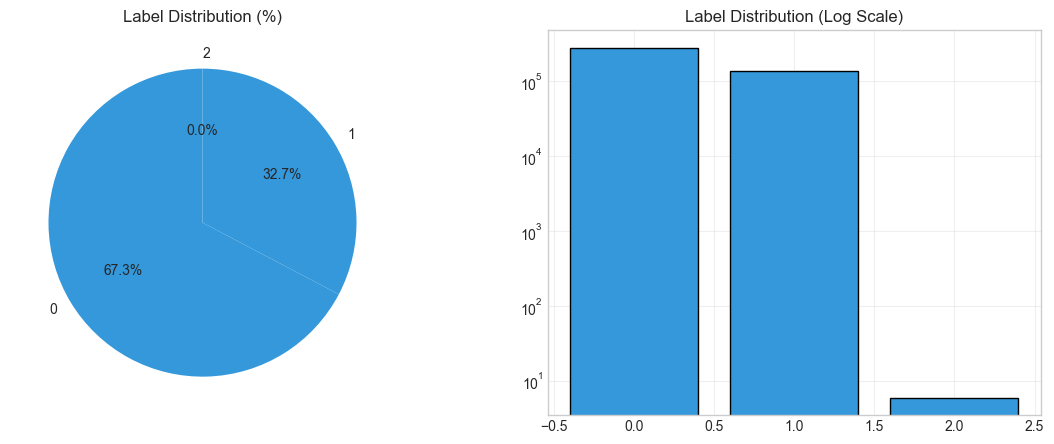

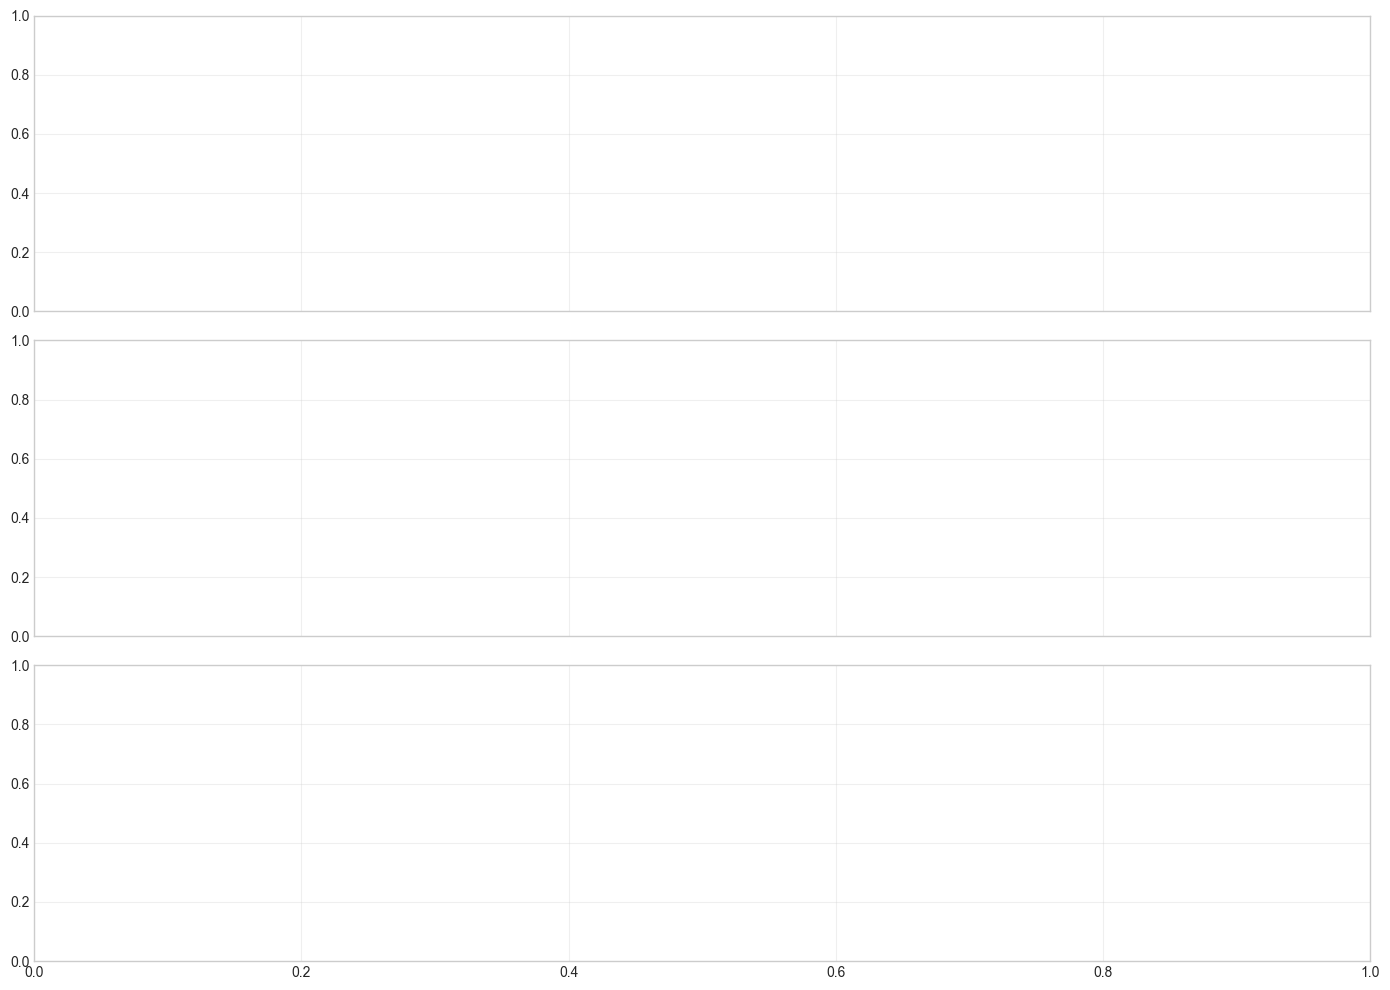

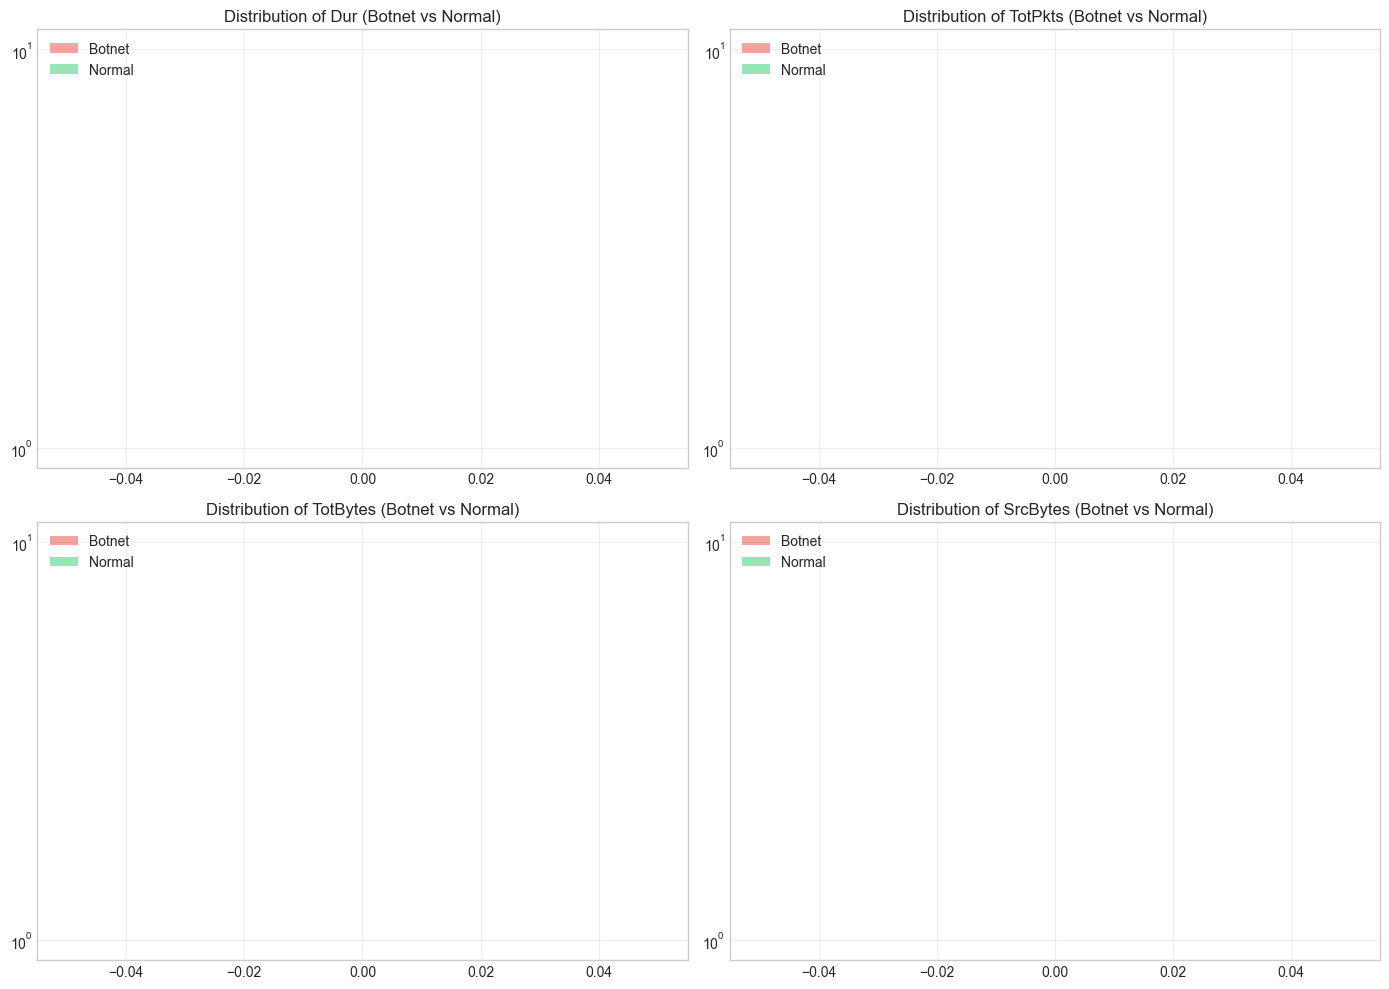

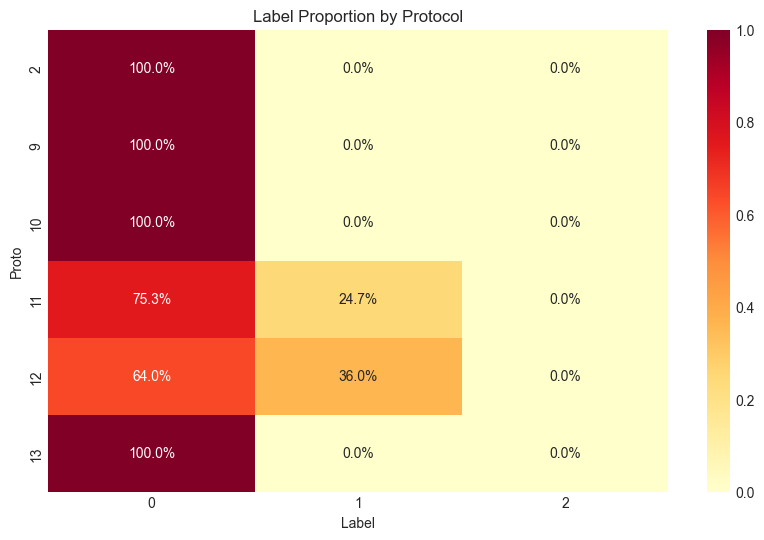

[INFO] Computing entropy preview...


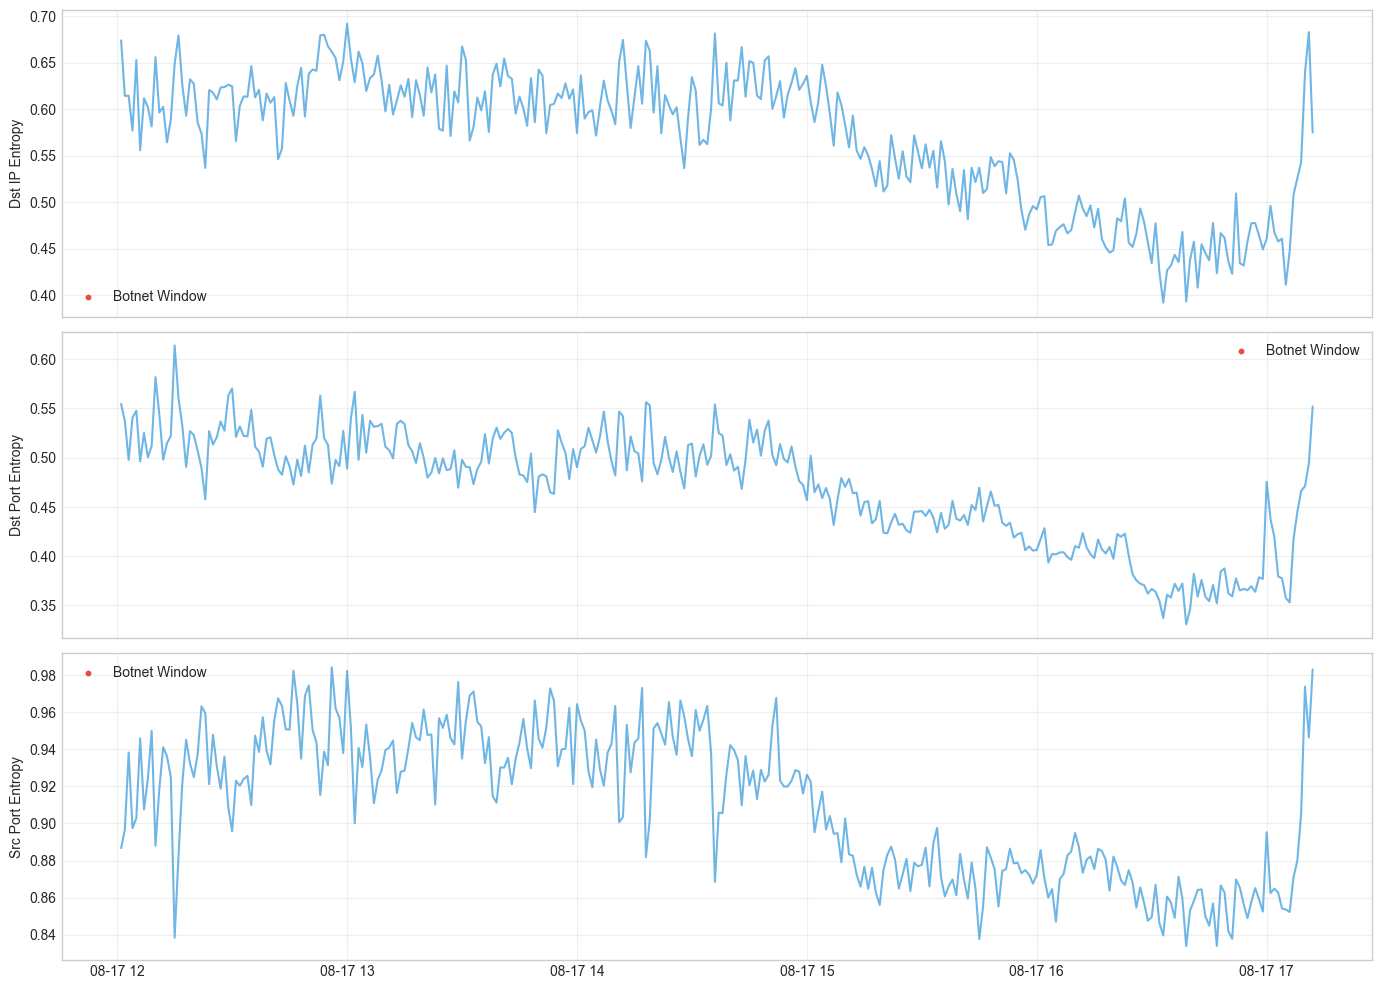

,StartTime,Dur,Proto,SrcAddr,Sport,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes,Label
0,2011-08-17 11:40:19.495285,1973.646729,12,151.28.221.122,6881.0,147.32.84.118,6881.0,6,0.0,0.0,2,214,107,0
1,2011-08-17 12:01:01.787415,196.055695,11,80.246.200.81,64872.0,147.32.87.27,80.0,107,0.0,0.0,6175,5977561,134036,0
2,2011-08-17 12:01:01.813101,2521.126221,12,82.117.234.33,23989.0,147.32.86.165,12114.0,6,0.0,0.0,4,265,142,0
4,2011-08-17 12:01:01.833664,0.000449,12,125.27.102.100,15697.0,147.32.86.165,12114.0,6,0.0,0.0,2,134,73,0
5,2011-08-17 12:01:01.833919,3598.763428,11,147.32.85.74,1423.0,78.108.97.41,39746.0,98,0.0,0.0,1690,283125,165519,0


[FIT] Building feature matrix for training...
[FIT] Model fitted on 3034 samples. Variance explained: 86.7%
      time_window                       time         src_ip  true_label  \
0               0 2011-08-17 16:21:28.789050  147.32.84.118           0   
1               0 2011-08-17 16:21:28.789050  147.32.84.123           0   
2               0 2011-08-17 16:21:28.789050  147.32.84.165           1   
3               0 2011-08-17 16:21:28.789050  147.32.84.181           0   
4               0 2011-08-17 16:21:28.789050  147.32.84.191           1   
...           ...                        ...            ...         ...   
1085           50 2011-08-17 17:11:29.236318  147.32.86.135           0   
1086           50 2011-08-17 17:11:29.236318  147.32.86.141           0   
1087           50 2011-08-17 17:11:29.236318   147.32.86.20           0   
1088           50 2011-08-17 17:11:29.236318  147.32.86.208           0   
1089           50 2011-08-17 17:11:29.236318  147.32.86.223        

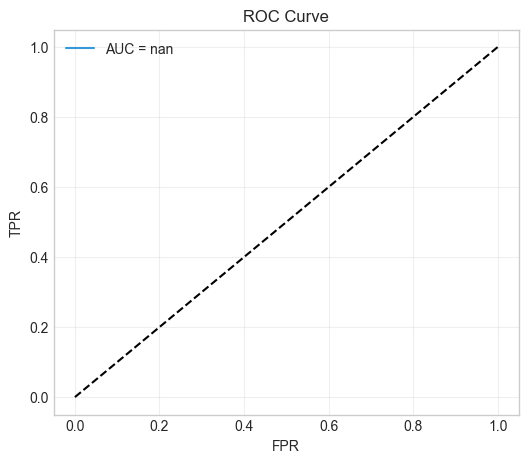

,time_window,time,src_ip,true_label,anomaly_score,is_anomaly
0,0,2011-08-17 16:21:28.789050,147.32.84.118,0,0.777267,True
1,0,2011-08-17 16:21:28.789050,147.32.84.123,0,0.521338,True
2,0,2011-08-17 16:21:28.789050,147.32.84.165,1,0.152135,False
3,0,2011-08-17 16:21:28.789050,147.32.84.181,0,0.787303,True
4,0,2011-08-17 16:21:28.789050,147.32.84.191,1,0.292365,False
...,...,...,...,...,...,...
1085,50,2011-08-17 17:11:29.236318,147.32.86.135,0,0.552897,True
1086,50,2011-08-17 17:11:29.236318,147.32.86.141,0,0.234185,False
1087,50,2011-08-17 17:11:29.236318,147.32.86.20,0,0.489215,False
1088,50,2011-08-17 17:11:29.236318,147.32.86.208,0,0.493497,False


In [108]:
if __name__ == "__main__":
    try:
        
        # 1. Loading
        df = load_and_clean_data(DATASET_PATH)
        display(df.head())
        print(df.isna().sum())
        df = df.dropna()
        df = df.drop(['Dir'], axis = 1)
        print(df.shape)
        display(df.head(10))
        
    #     # 2. EDA
        print_summary(df)
        plot_label_distribution(df)
        plot_traffic_over_time(df, window='5min')
        plot_feature_distributions(df)
        plot_protocol_by_label(df)
        compute_entropy_preview(df)
        
        display(df.head())
    #     # 3. Training & Testing Splits
        df_train, df_val, df_test = split_dataset(df)
        
    #     # 4. Detector Setup & Training
        detector = LakhinaEntropyDetector(window_seconds=60)
        detector.fit(df_train)
        
    #     # 5. Detection on Test Set
        res_test = detector.predict(df_test)
        res = pd.DataFrame(res_test)
        
    #     # 6. Final Evaluation
        if not res_test.empty:
            evaluator = DetectionEvaluator(res_test)
            evaluator.report()
            evaluator.plot_roc()
    
        display(res)
        res.value_counts()            
    except Exception as e:
        print(f"❌ Error occurred: {e}")